# Pipeline: Preprocesamiento y Modelos
Flujo completo de datos: carga -> preprocesamiento -> entrenamiento -> evaluación.

In [ ]:
# --- 1: Imports y carga de datos ------------------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Limpieza básica: conversión de TotalCharges a numérico, remoción de nulos y descarte de customerID
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(subset=["TotalCharges"], inplace=True)
df.drop(columns=["customerID"], inplace=True)

# Codificación binaria de la variable objetivo
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(f"Dataset listo: {df.shape[0]} filas × {df.shape[1]} columnas")

Dataset listo: 7032 filas × 20 columnas


In [ ]:
# --- 2: Preprocesamiento -------------------------------------

# Separación de variables independientes (X) y objetivo (y)
X = df.drop(columns="Churn")
y = df["Churn"]

# División estratificada en entrenamiento, validación y prueba (64% / 16% / 20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

# Detección de columnas por tipo 
columnas_num = X.select_dtypes(include="number").columns.tolist()
columnas_cat = X.select_dtypes(include=["object", "str"]).columns.tolist()

# Configuración del flujo de transformación
preprocesador = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), columnas_num),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), columnas_cat)
])

print(f"Columnas numéricas ({len(columnas_num)}): {columnas_num}")
print(f"Columnas categóricas ({len(columnas_cat)}): {columnas_cat}")
print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Columnas numéricas (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Columnas categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Train: 4500 | Val: 1125 | Test: 1407


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.83      0.88      0.86       826
           1       0.61      0.52      0.56       299

    accuracy                           0.78      1125
   macro avg       0.72      0.70      0.71      1125
weighted avg       0.78      0.78      0.78      1125

ROC-AUC: 0.8371225311166358

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.88      0.76      0.82       826
           1       0.52      0.72      0.60       299

    accuracy                           0.75      1125
   macro avg       0.70      0.74      0.71      1125
weighted avg       0.79      0.75      0.76      1125

ROC-AUC: 0.8250909002567071


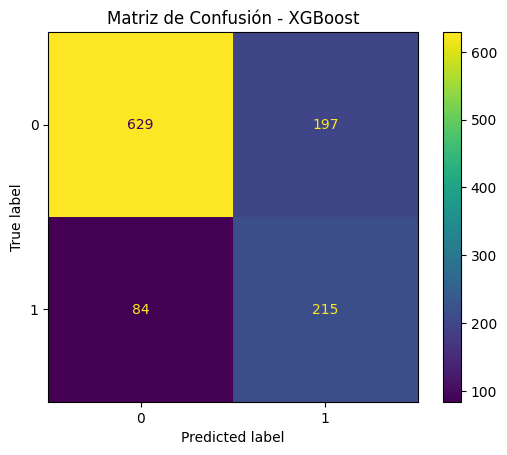

In [ ]:
# --- 3: Entrenamiento y evaluación de modelos --------------

# --- Regresión Logística (Baseline) ---
modelo_lr = Pipeline([
    ("prep", preprocesador),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_val)
print("=== Logistic Regression ===")
print(classification_report(y_val, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_val, modelo_lr.predict_proba(X_val)[:,1]))

# --- XGBoost (Modelo Principal) ---
modelo_xgb = Pipeline([
    ("prep", preprocesador),
    ("clf", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        scale_pos_weight=3,  # Ajuste de escala para mitigar el desbalanceo de clases
        eval_metric="logloss",
        random_state=42
    ))
])
modelo_xgb.fit(X_train, y_train)

y_pred_xgb = modelo_xgb.predict(X_val)
print("\n=== XGBoost ===")
print(classification_report(y_val, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_val, modelo_xgb.predict_proba(X_val)[:,1]))

# Visualización de la matriz de confusión para el modelo seleccionado
ConfusionMatrixDisplay.from_estimator(modelo_xgb, X_val, y_val)
plt.title("Matriz de Confusión - XGBoost")
plt.show()

### Justificación Teórica: Recall y F1-Score en Predicción de Churn

En este proyecto de predicción de fuga de clientes (*Churn*), priorizamos las métricas **Recall** (Sensibilidad) y **F1-Score** por encima del accuracy global o la precisión por las siguientes razones:

1. **Costo Asimétrico de los Errores (Priorización de Recall):**
   * **Falso Negativo (FN):** Clasificamos a un cliente que realmente se va a fugar como "leal". Como consecuencia, no tomamos ninguna acción y el cliente abandona la compañía. El costo de perder un cliente (CAC + pérdida de ingresos recurrentes) es extremadamente alto.
   * **Falso Positivo (FP):** Clasificamos a un cliente leal como "en riesgo de fuga" y le enviamos una oferta de retención. Esto tiene un costo menor (el margen de la oferta de retención), pero es preferible para conservar al cliente.
   * Por lo tanto, priorizamos un **Recall alto** para capturar al máximo número de clientes propensos a fugarse y minimizar los Falsos Negativos.

2. **Equilibrio Necesario ante Clases Desbalanceadas (Priorización de F1-Score):**
   * Si solo nos importara el Recall, el modelo podría predecir que todos los clientes van a fugarse (Recall del 100%), lo cual haría financieramente inviable cualquier campaña de retención.
   * El **F1-Score** es la media armónica entre Precision y Recall. Nos asegura que, mientras buscamos un Recall alto, el modelo mantenga una buena precisión para no inundar el departamento de marketing con Falsos Positivos innecesarios.